In [1]:
from model import *
import numpy as np
import random
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
import pandas as pd
from model.initialization import init_blocks_spectral, init_spectral_with_z
from helper_functions.Generate_mixture_data import * 

from helper_functions.Estimate_p import estimate_p_multicluster, match_clusters

In [2]:
import urllib.request
import numpy as np

# Download the "sushi3" archive from Kamishima's site
url = "https://www.kamishima.net/asset/sushi3-2016.zip"
urllib.request.urlretrieve(url, "sushi3.zip")

import zipfile
with zipfile.ZipFile("sushi3.zip", "r") as z:
    z.extractall("sushi3")

In [3]:
# Parse sushi3a rankings
# Format: each line is "<user_id> <n_items> <rank_1> ... <rank_10>"
# First line is a header
rankings = []
with open("sushi3/sushi3-2016/sushi3a.5000.10.order") as f:
    for i, line in enumerate(f):
        if i == 0:
            continue  # skip header
        parts = line.strip().split()
        ranking = [int(x) for x in parts[2:]]  # skip user_id and n_items
        rankings.append(ranking)

rankings = np.array(rankings)  # shape (5000, 10)
print(f"Rankings: {rankings.shape[0]} assessors, {rankings.shape[1]} sushi types")
print(f"Items: {sorted(np.unique(rankings))}")

Rankings: 5000 assessors, 10 sushi types
Items: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [4]:
C = 20
gamma = 1
delta = 0.5

# Initate with spectral clustering
clusters, z_init = init_spectral_with_z(
    rankings=rankings,
    n_clusters=C,
    py_sampling=False,  # Use simpler ~n/2 blocks
    gamma=gamma,
    delta=delta,
    seed=123, 
    affinity="rbf"
    )

KeyboardInterrupt: 

In [6]:
n_iter = 50000 # Same as Bayesian Rank Clustering paper
burn_in = 30000
thin = 1
init_mu = [1/(2*C) for _ in range(C)] 

model_partial = MixtureRankingModel(
    rankings=rankings,
    #init_clusters=clusters,
    # init_z=z_i,
    n_clusters=C,
    init_mu=init_mu,
    seed=123,
    verbose=True,
    init_theta=1.0,
)

final_state_partial, samples_partial = model_partial.run_mcmc(
    n_iter=n_iter,
    burn_in=burn_in,
    thin=thin,
    use_py_prior=False,
    include_order_prior=False,
    save_samples=True,
    save_tau=True,
    save_theta=True,
    n_item_moves_per_cluster=1,
    gamma=gamma,
    delta=delta,
    a_theta=4,
    b_theta=1,
    theta_jump=10,
    ranking_jump=5,              # augment missing drivers every 5th iteration
    use_annealing=True,
    temp_min=0.1,
    temp_max=1.0,
)

model_partial.print_acceptance_summary()

if samples_partial is not None:
    summaries_partial = model_partial.estimate_map(samples_partial, ci=0.95)
    print("MAP summaries:", summaries_partial)


C:\Users\jonanord\AppData\Local\Temp\ipykernel_17532\1408349005.py:6: UserWarning: init_clusters not provided. For best results supply them via init_spectral_with_z(rankings, n_clusters=C, seed=...). Falling back to trivial initialization.
  model_partial = MixtureRankingModel(


[Model] Initialized: N=5000 assessors, n=10 items, C=20 clusters, n_pairs=45
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    5000×45  (0.9 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 10: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 11: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 12: 5 blocks, theta=1.0

In [7]:
map_result = model_partial.find_map(samples_partial, refine=True, verbose=True)

z_map = map_result["z"]
for c, cl in enumerate(map_result["clusters"]):
    if c in z_map:
        print(f"Cluster {c}: {cl['blocks']}")

[MAP] Best sample at t=5957 with logp=-69501.3249
  Cluster 2: 0 moves in 1 sweeps, K=5 blocks
  Cluster 16: 0 moves in 1 sweeps, K=2 blocks
[MAP] logp: -69501.3249 → -69501.3249 (Δ=+0.0000)
Cluster 2: [[7], [0, 1, 2, 4, 5], [3, 8], [6], [9]]
Cluster 16: [[0, 1, 2, 3, 5, 6, 7, 8, 9], [4]]


In [8]:
import json
import pickle
from pathlib import Path
from datetime import datetime

# ── Choose a run directory ────────────────────────────────────────────────────
SUSHI_RUNS_DIR = Path("sushi3/runs")
run_name = f"sushi_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir  = SUSHI_RUNS_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=True)

# ── 1. MCMC parameters — human-readable JSON ─────────────────────────────────
mcmc_params = dict(
    # Data
    n_assessors   = len(rankings),
    n_items       = rankings.shape[1],
    # Cluster init
    C             = C,
    gamma         = gamma,
    delta         = delta,
    # run_mcmc call
    n_iter        = n_iter,
    burn_in       = burn_in,
    thin          = thin,
    n_item_moves_per_cluster = 1,
    a_theta       = 4,
    b_theta       = 1,
    theta_jump    = 10,
    ranking_jump  = 5,
    use_annealing = True,
    temp_min      = 0.1,
    temp_max      = 1.0,
    # Provenance
    run_name      = run_name,
    saved_at      = datetime.now().isoformat(),
)
with open(run_dir / "mcmc_params.json", "w") as f:
    json.dump(mcmc_params, f, indent=2)

# ── 2. MAP result — JSON ─────────────────────────────────────────────────────
if samples_partial is not None:
    map_serialisable = {}
    for key, val in summaries_partial.items():
        if isinstance(val, (int, float, str, bool)):
            map_serialisable[key] = val
        elif isinstance(val, np.integer):
            map_serialisable[key] = int(val)
        elif isinstance(val, np.floating):
            map_serialisable[key] = float(val)
        elif isinstance(val, (list, dict)):
            map_serialisable[key] = val
    with open(run_dir / "map_result.json", "w") as f:
        json.dump(map_serialisable, f, indent=2, default=str)

# ── 3. Full MCMC samples — pickle ────────────────────────────────────────────
with open(run_dir / "samples.pkl", "wb") as f:
    pickle.dump(samples_partial, f)

# ── 4. Final model state — pickle ────────────────────────────────────────────
with open(run_dir / "final_state.pkl", "wb") as f:
    pickle.dump(final_state_partial, f)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Run saved to: {run_dir}")
for p in sorted(run_dir.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<25}  {size_kb:>8.1f} KB")

Run saved to: sushi3\runs\sushi_20260413_155012
  final_state.pkl                41.2 KB
  map_result.json              1548.4 KB
  mcmc_params.json                0.4 KB
  samples.pkl                808666.4 KB


In [34]:
import json
import pickle
from pathlib import Path

# ── Select run to load ────────────────────────────────────────────────────────
RUN_NAME = run_name  # or paste a specific name, e.g. "sushi_20260410_153000"
run_dir  = Path("sushi3/runs") / RUN_NAME

# ── 1. MCMC parameters ────────────────────────────────────────────────────────
with open(run_dir / "mcmc_params.json") as f:
    mcmc_params = json.load(f)

C             = mcmc_params["C"]
gamma         = mcmc_params["gamma"]
delta         = mcmc_params["delta"]
p_hat         = mcmc_params["p_hat"]

print(f"Run: {RUN_NAME}")
print(f"  C={C}, n_assessors={mcmc_params['n_assessors']}, n_items={mcmc_params['n_items']}")
print(f"  p_hat={p_hat:.4f}, saved at {mcmc_params['saved_at']}")

# ── 2. MCMC samples ──────────────────────────────────────────────────────────
with open(run_dir / "samples.pkl", "rb") as f:
    samples_partial = pickle.load(f)

# ── 3. Final model state ─────────────────────────────────────────────────────
with open(run_dir / "final_state.pkl", "rb") as f:
    final_state_partial = pickle.load(f)

# ── 4. MAP result (if saved) ─────────────────────────────────────────────────
map_path = run_dir / "map_result.json"
if map_path.exists():
    with open(map_path) as f:
        summaries_partial = json.load(f)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nLoaded successfully:")
print(f"  {len(samples_partial.z_samples)} posterior samples")
for p in sorted(run_dir.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<25}  {size_kb:>8.1f} KB")

Run: sushi_20260410_155719
  C=20, n_assessors=5000, n_items=11
  p_hat=0.4359, saved at 2026-04-10T15:57:19.204059

Loaded successfully:
  12000 posterior samples
  final_state.pkl                41.2 KB
  map_result.json              1675.2 KB
  mcmc_params.json                0.5 KB
  samples.pkl                486389.0 KB


In [9]:
# ── Sushi item names for ITEM SET A (sushi3a) ─────────────────────────────────
# NB: Item set A has DIFFERENT items 5-9 than item set B!
#   A: 5=ikura, 6=tamago, 7=toro, 8=tekka_maki, 9=kappa_maki
#   B: 5=tako,  6=ikura,  7=tamago, 8=toro,      9=amaebi
sushi_names = {
    0: "Shrimp (ebi)",
    1: "Sea eel (anago)",
    2: "Tuna (maguro)",
    3: "Squid (ika)",
    4: "Sea urchin (uni)",
    5: "Salmon roe (ikura)",
    6: "Egg (tamago)",
    7: "Fatty tuna (toro)",
    8: "Tuna roll (tekka maki)",
    9: "Cucumber roll (kappa maki)",
}

n_ranked = rankings.shape[1]
print(f"Sushi items in rankings (item set A): {n_ranked}")
for i in range(n_ranked):
    print(f"  {i}: {sushi_names[i]}")

Sushi items in rankings (item set A): 10
  0: Shrimp (ebi)
  1: Sea eel (anago)
  2: Tuna (maguro)
  3: Squid (ika)
  4: Sea urchin (uni)
  5: Salmon roe (ikura)
  6: Egg (tamago)
  7: Fatty tuna (toro)
  8: Tuna roll (tekka maki)
  9: Cucumber roll (kappa maki)


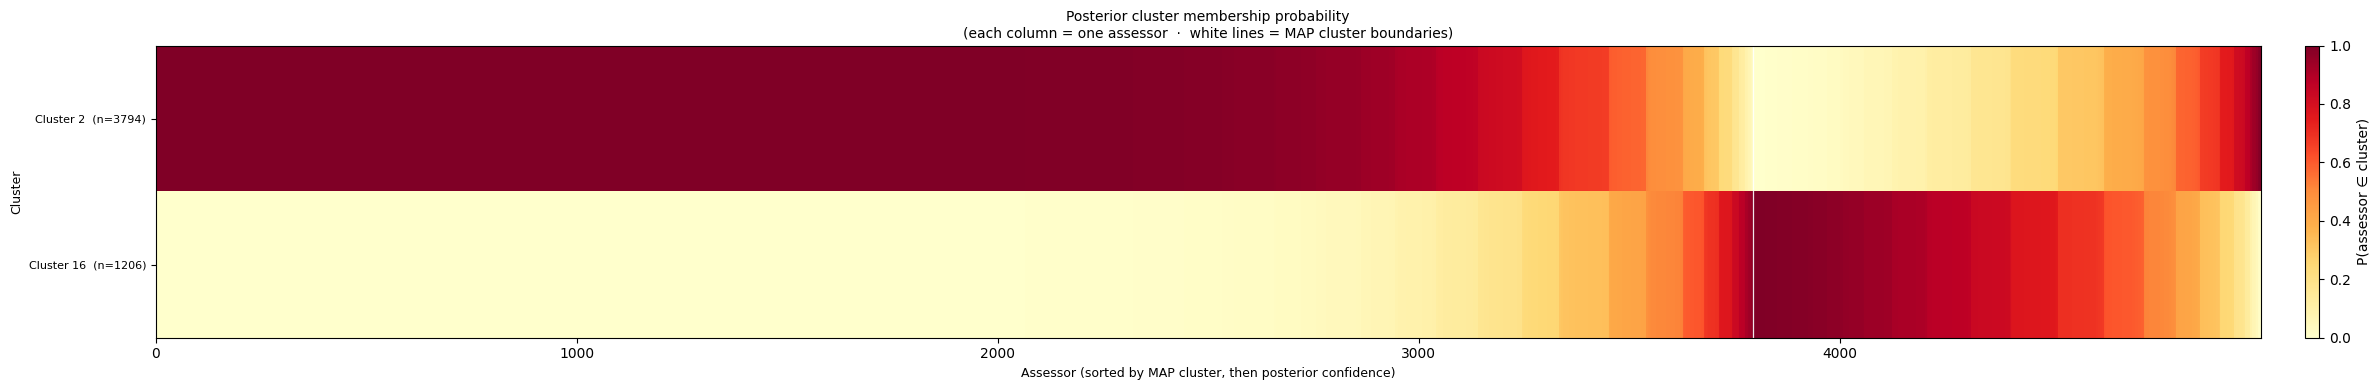


2 active clusters out of 20
Cluster sizes: Cl2=3794, Cl16=1206


In [10]:
# ── Posterior cluster membership heatmap ──────────────────────────────────────
import matplotlib.pyplot as plt

z_arr   = np.array(samples_partial.z_samples, dtype=np.intp)   # (T, N)
T_samp  = z_arr.shape[0]
N_assess = z_arr.shape[1]

# Use MAP z from find_map (or estimate_map labels as fallback)
if "map_result" in dir() and map_result is not None:
    z_map = map_result["z"]
elif "summaries_partial" in dir() and "labels" in summaries_partial:
    z_map = summaries_partial["labels"]
else:
    raise RuntimeError("Run find_map() or estimate_map() first")

# Membership matrix: membership[i, c] = fraction of samples where assessor i was in cluster c
membership = np.zeros((N_assess, C), dtype=np.float32)
for t in range(T_samp):
    membership[np.arange(N_assess), z_arr[t]] += 1
membership /= T_samp

# Sort assessors by MAP cluster, then by posterior confidence
z_map_arr  = np.array(z_map, dtype=int)
confidence = membership[np.arange(N_assess), z_map_arr]
sort_ord   = np.lexsort((-confidence, z_map_arr))
boundaries = np.where(np.diff(z_map_arr[sort_ord]))[0]

# Sort clusters by size (largest first), exclude empty
cluster_sizes = np.array([(z_map_arr == c).sum() for c in range(C)])
active_clusters = [c for c in np.argsort(-cluster_sizes) if cluster_sizes[c] > 0]

mem_display = membership[sort_ord][:, active_clusters]

# Plot
fig, ax = plt.subplots(figsize=(max(12, N_assess * 0.004 + 4), max(4, len(active_clusters) * 0.4 + 2)))

im = ax.imshow(
    mem_display.T, vmin=0, vmax=1, cmap="YlOrRd",
    aspect="auto", interpolation="nearest",
)

for b in boundaries:
    ax.axvline(b + 0.5, color="white", lw=0.9, alpha=0.9)

ax.set_yticks(range(len(active_clusters)))
ax.set_yticklabels(
    [f"Cluster {c}  (n={cluster_sizes[c]})" for c in active_clusters],
    fontsize=8,
)
ax.set_xlabel("Assessor (sorted by MAP cluster, then posterior confidence)", fontsize=9)
ax.set_ylabel("Cluster", fontsize=9)
ax.set_title(
    "Posterior cluster membership probability\n"
    "(each column = one assessor  ·  white lines = MAP cluster boundaries)",
    fontsize=10,
)
plt.colorbar(im, ax=ax, label="P(assessor ∈ cluster)", fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

print(f"\n{len(active_clusters)} active clusters out of {C}")
print(f"Cluster sizes: {', '.join(f'Cl{c}={cluster_sizes[c]}' for c in active_clusters)}")

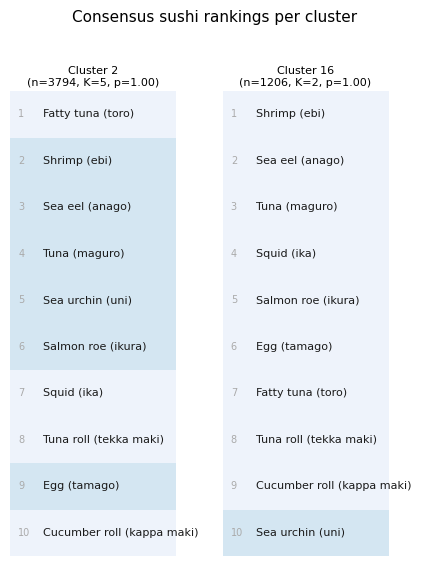

Showing 2/20 clusters (filter: ≥10 assessors)


In [11]:
# ── Consensus rankings per cluster ────────────────────────────────────────────
import matplotlib.pyplot as plt

MIN_ASSESSORS = 10  # exclude tiny clusters

# Filter to meaningful clusters
cluster_order = [c for c in active_clusters if cluster_sizes[c] >= MIN_ASSESSORS]

# Get blocks from map_result (find_map) or summaries_partial (estimate_map)
def get_cluster_blocks(c):
    """Return (blocks, label_str) for cluster c from whichever MAP source is available."""
    if "map_result" in dir() and map_result is not None:
        bl = map_result["clusters"][c]["blocks"]
        theta = map_result["clusters"][c].get("theta", None)
        lbl = f"θ={theta:.2f}" if theta is not None else ""
        return bl, lbl
    else:
        info = summaries_partial["consensus_blocks"][c]
        bl = info["blocks_hat"]
        pp = float(info["posterior_prob"])
        return bl, f"p={pp:.2f}"

if not cluster_order:
    print("No clusters passed the filter — lower MIN_ASSESSORS.")
else:
    block_bg = ["#eef3fb", "#d4e6f2"]
    ncols = len(cluster_order)

    fig, axes = plt.subplots(
        1, ncols,
        figsize=(ncols * 2.2, n_ranked * 0.4 + 1.5),
        squeeze=False,
    )

    for col, c in enumerate(cluster_order):
        blocks, extra_lbl = get_cluster_blocks(c)
        n_c = int(cluster_sizes[c])

        # Count total items across blocks (may be < n_ranked if some items are grouped)
        total_items = sum(len(b) for b in blocks)

        ax = axes[0, col]
        ax.set_xlim(0, 1)
        ax.set_ylim(0, total_items)
        ax.invert_yaxis()
        ax.axis("off")

        rank_pos = 1
        row_i = 0
        toggle = 0
        for b_idx, block in enumerate(blocks):
            toggle = b_idx % 2
            for item_idx in block:
                name = sushi_names.get(item_idx, f"item {item_idx}")
                ax.add_patch(plt.Rectangle(
                    (0, row_i), 1, 1,
                    facecolor=block_bg[toggle], edgecolor="none", zorder=1,
                ))
                ax.text(0.05, row_i + 0.5, str(rank_pos),
                        fontsize=7, va="center", ha="left", color="#aaaaaa", zorder=2)
                ax.text(0.20, row_i + 0.5, name,
                        fontsize=8, va="center", ha="left", color="#1a1a1a", zorder=2)
                rank_pos += 1
                row_i += 1

        ax.set_title(
            f"Cluster {c}\n(n={n_c}, K={len(blocks)}, {extra_lbl})",
            fontsize=8, pad=4,
        )

    fig.suptitle("Consensus sushi rankings per cluster", fontsize=11, y=1.02)
    fig.tight_layout()
    plt.show()

    print(f"Showing {ncols}/{C} clusters (filter: ≥{MIN_ASSESSORS} assessors)")

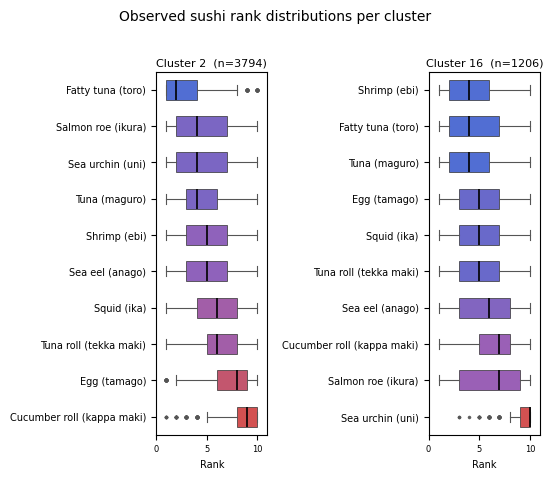

In [12]:
# ── Observed rank distributions per cluster (box plots) ───────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

if not cluster_order:
    print("No clusters to plot — lower MIN_ASSESSORS.")
else:
    ncols_bp = len(cluster_order)

    # Blue → purple → red colormap
    rank_cmap = mcolors.LinearSegmentedColormap.from_list(
        "blue_purple_red", ["#3355cc", "#8844aa", "#cc3333"]
    )

    fig_bp, axes_bp = plt.subplots(
        1, ncols_bp,
        figsize=(ncols_bp * 2.8, n_ranked * 0.35 + 1.2),
        squeeze=False,
    )

    for col, c in enumerate(cluster_order):
        # Assessors in this cluster
        cl_assessors = [i for i, z in enumerate(z_map) if z == c]

        # Collect rank positions for each sushi item across assessors in this cluster
        item_ranks = defaultdict(list)
        for ai in cl_assessors:
            for rank_0, item_idx in enumerate(rankings[ai]):
                item_ranks[item_idx].append(rank_0 + 1)  # 1-indexed

        # Sort by median rank
        stats = []
        for item_idx, ranks_list in item_ranks.items():
            arr = np.array(ranks_list)
            stats.append({
                "item": item_idx,
                "name": sushi_names.get(item_idx, f"item {item_idx}"),
                "median": np.median(arr),
                "ranks": ranks_list,
            })
        stats.sort(key=lambda x: x["median"])

        ax = axes_bp[0, col]
        names = [s["name"] for s in stats]
        medians = [s["median"] for s in stats]
        rank_data = [s["ranks"] for s in stats]

        rank_norm = mcolors.Normalize(vmin=min(medians), vmax=max(medians))
        box_colors = [rank_cmap(rank_norm(m)) for m in medians]

        bp = ax.boxplot(
            rank_data, vert=False, patch_artist=True,
            widths=0.55,
            flierprops=dict(marker=".", markersize=3, markerfacecolor="#555555",
                            markeredgecolor="#555555", alpha=0.6),
            medianprops=dict(color="black", linewidth=1.2),
            whiskerprops=dict(color="#555555", linewidth=0.8),
            capprops=dict(color="#555555", linewidth=0.8),
        )
        for patch, fc in zip(bp["boxes"], box_colors):
            patch.set_facecolor(fc)
            patch.set_edgecolor("#333333")
            patch.set_linewidth(0.6)
            patch.set_alpha(0.85)

        ax.set_yticks(range(1, len(stats) + 1))
        ax.set_yticklabels(names, fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel("Rank", fontsize=7)
        ax.set_title(f"Cluster {c}  (n={cluster_sizes[c]})", fontsize=8, pad=4)
        ax.tick_params(axis="x", labelsize=6)
        ax.set_xlim(0, n_ranked + 1)

    fig_bp.suptitle(
        "Observed sushi rank distributions per cluster",
        fontsize=10, y=1.01,
    )
    fig_bp.tight_layout()
    plt.show()

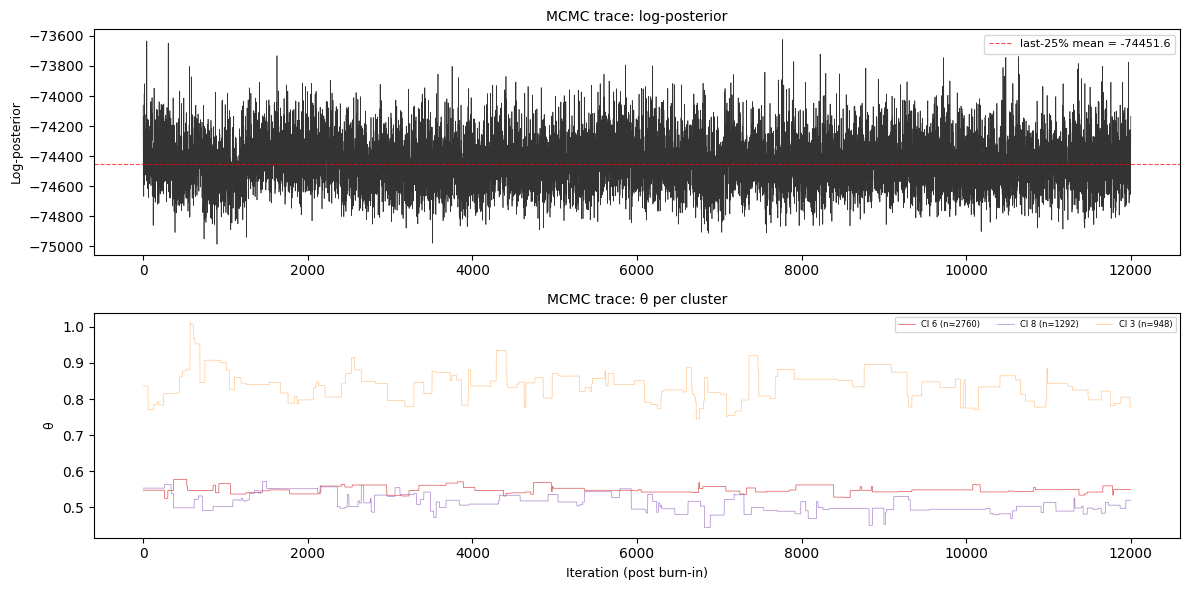

In [41]:
# ── MCMC diagnostics: log-posterior trace + theta traces ──────────────────────
import matplotlib.pyplot as plt

has_logp  = hasattr(samples_partial, "logp") and samples_partial.logp is not None
has_theta = hasattr(samples_partial, "theta_samples") and samples_partial.theta_samples is not None
n_panels  = int(has_logp) + int(has_theta)

if n_panels == 0:
    print("No logp or theta samples saved — run MCMC with save_logp=True, save_theta=True")
else:
    fig, axes = plt.subplots(n_panels, 1, figsize=(12, 3 * n_panels), squeeze=False)
    ax_idx = 0

    # 1. Log-posterior trace
    if has_logp:
        logp = np.array(samples_partial.logp)
        ax = axes[ax_idx, 0]
        ax.plot(logp, lw=0.5, color="#333333")
        ax.set_ylabel("Log-posterior", fontsize=9)
        ax.set_title("MCMC trace: log-posterior", fontsize=10)
        tail = logp[-len(logp)//4:]
        ax.axhline(tail.mean(), color="red", ls="--", lw=0.8, alpha=0.7,
                   label=f"last-25% mean = {tail.mean():.1f}")
        ax.legend(fontsize=8)
        ax_idx += 1

    # 2. Theta traces (one line per active cluster)
    if has_theta:
        theta_arr = np.array(samples_partial.theta_samples)  # (T, C)
        ax = axes[ax_idx, 0]
        cmap_theta = plt.get_cmap("tab20", C)
        for c in active_clusters:
            ax.plot(theta_arr[:, c], lw=0.5, color=cmap_theta(c), alpha=0.8,
                    label=f"Cl {c} (n={cluster_sizes[c]})")
        ax.set_ylabel("θ", fontsize=9)
        ax.set_xlabel("Iteration (post burn-in)", fontsize=9)
        ax.set_title("MCMC trace: θ per cluster", fontsize=10)
        ax.legend(fontsize=6, ncol=4, loc="upper right")

    plt.tight_layout()
    plt.show()

# Bayesian rank clustering data

In [62]:
"""
Extract the Tohoku sushi ranking subset used in:

  Pearce & Johnson (2024). "Bayesian Rank-Clustering." Psychometrika.

The paper uses complete rankings of 10 sushi types from respondents who
lived in Japan's Tohoku region until at least 15 years of age (n=280),
following Piancastelli & Friel (2025).

Data source:
  Kamishima, T. (2003). "Nantonac Collaborative Filtering."
  SUSHI Preference Data Set: https://www.kamishima.net/sushi/
  Download "All Data Set": sushi3-2016.zip
"""

import csv
import os
import sys
import numpy as np
from pathlib import Path

# ──────────────────────────────────────────────────────────────────────
# Configuration — point to the extracted sushi3-2016 folder
# ──────────────────────────────────────────────────────────────────────
DATA_DIR = Path("sushi3/sushi3-2016")

# File paths within the extracted archive
UDATA_FILE = DATA_DIR / "sushi3.udata"        # user demographics
ORDER_FILE = DATA_DIR / "sushi3a.5000.10.order"  # complete rankings of 10 sushi types

# ──────────────────────────────────────────────────────────────────────
# sushi3.udata column layout (tab-separated, from README-en.txt):
#
#   Col 0: user_id
#   Col 1: gender           — 0 = male, 1 = female
#   Col 2: age_group        — 0 = 15–19, 1 = 20–29, …, 5 = 60+
#   Col 3: total_time       — total survey time in seconds
#   Col 4: prefecture_15    — prefecture ID where respondent lived most until age 15
#   Col 5: region_15        — region ID where respondent lived most until age 15
#   Col 6: prefecture_now   — current prefecture ID
#   Col 7: region_now       — current region ID
#   Col 8: same_pref_flag   — 1 if prefecture_15 == prefecture_now, else 0
#   Col 9+: additional fields
#
# Region codes:
#   0 = Hokkaido, 1 = Tohoku, 2 = Kanto, 3 = Chubu, 4 = Kinki,
#   5 = Chugoku, 6 = Shikoku, 7 = Kyushu
# ──────────────────────────────────────────────────────────────────────

REGION_15_COL = 5   # column index for "region lived in until age 15"
TOHOKU_CODE = 1     # region code for Tohoku

# Sushi item IDs (set A, 0-indexed)
SUSHI_NAMES = {
    0: "ebi (shrimp)",
    1: "anago (sea eel)",
    2: "maguro (tuna)",
    3: "ika (squid)",
    4: "uni (sea urchin)",
    5: "ikura (salmon roe)",
    6: "tamago (egg)",
    7: "toro (fatty tuna)",
    8: "tekka-maki (tuna roll)",
    9: "kappa-maki (cucumber roll)",
}


def load_user_demographics(filepath: Path) -> list[list[str]]:
    """Load sushi3.udata (tab-separated) and return list of row-lists."""
    rows = []
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(line.split("\t"))
    print(f"Loaded {len(rows)} user records from {filepath}")
    return rows


def load_rankings(filepath: Path) -> list[list[int]]:
    """
    Load sushi3a.5000.10.order and return list of ranking vectors.

    Each ranking vector is a list of 10 sushi IDs ordered from most
    preferred (position 0) to least preferred (position 9).
    """
    rankings = []
    with open(filepath, "r") as f:
        for i, line in enumerate(f):
            if i == 0:
                continue  # skip header line
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            # Format: 0 <num_items> <item_1> ... <item_num_items>
            num_items = int(parts[1])
            items = [int(x) for x in parts[2 : 2 + num_items]]
            rankings.append(items)
    print(f"Loaded {len(rankings)} rankings from {filepath}")
    return rankings


def filter_tohoku(
    users: list[list[str]], rankings: list[list[int]]
) -> tuple[list[int], list[list[int]]]:
    """
    Filter to respondents whose region_15 == Tohoku (code 1).

    Returns (indices, filtered_rankings).
    """
    assert len(users) == len(rankings), (
        f"Mismatch: {len(users)} users vs {len(rankings)} rankings"
    )

    indices = []
    filtered = []
    for i, row in enumerate(users):
        region_15 = int(row[REGION_15_COL])
        if region_15 == TOHOKU_CODE:
            indices.append(i)
            filtered.append(rankings[i])

    print(f"Tohoku subset: {len(filtered)} respondents (expected: 280)")
    return indices, filtered


def ranking_to_rank_vector(ranking: list[int], n_items: int = 10) -> list[int]:
    """
    Convert a preference ordering to a rank vector.

    Input:  ranking[k] = sushi ID at position k (0 = most preferred)
    Output: ranks[j]   = rank of sushi j (1 = most preferred)
    """
    ranks = [0] * n_items
    for position, item_id in enumerate(ranking):
        ranks[item_id] = position + 1  # 1-indexed rank
    return ranks


def save_tohoku_data(
    indices: list[int],
    rankings: list[list[int]],
    out_dir: Path = Path("."),
):
    """Save the Tohoku subset in several convenient formats."""
    os.makedirs(out_dir, exist_ok=True)
    n = len(rankings)
    n_items = 10

    # 1. Rankings as preference orderings
    orderings_file = out_dir / "tohoku_sushi_orderings.csv"
    with open(orderings_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([f"choice_{k+1}" for k in range(n_items)])
        for ranking in rankings:
            writer.writerow(ranking)
    print(f"Saved preference orderings to {orderings_file}")

    # 2. Rank matrix
    rank_matrix_file = out_dir / "tohoku_sushi_ranks.csv"
    with open(rank_matrix_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([SUSHI_NAMES[j] for j in range(n_items)])
        for ranking in rankings:
            writer.writerow(ranking_to_rank_vector(ranking, n_items))
    print(f"Saved rank matrix to {rank_matrix_file}")

    # 3. NumPy array
    rank_matrix = np.array(
        [ranking_to_rank_vector(r, n_items) for r in rankings], dtype=int
    )
    npy_file = out_dir / "tohoku_sushi_ranks.npy"
    np.save(npy_file, rank_matrix)
    print(f"Saved numpy rank matrix ({rank_matrix.shape}) to {npy_file}")

    # 4. Summary statistics
    print(f"\n{'='*60}")
    print(f"TOHOKU SUSHI DATA SUMMARY")
    print(f"{'='*60}")
    print(f"Number of respondents:  {n}")
    print(f"Number of sushi types:  {n_items}")
    print(f"\nMean rank per sushi type (1 = most preferred):")
    mean_ranks = rank_matrix.mean(axis=0)
    sorted_idx = np.argsort(mean_ranks)
    for j in sorted_idx:
        print(f"  {mean_ranks[j]:5.2f}  {SUSHI_NAMES[j]}")


# ── Run ───────────────────────────────────────────────────────────────
if not UDATA_FILE.exists():
    raise FileNotFoundError(
        f"{UDATA_FILE} not found. Download sushi3-2016.zip from "
        "https://www.kamishima.net/sushi/ and extract to sushi3/"
    )
if not ORDER_FILE.exists():
    raise FileNotFoundError(f"{ORDER_FILE} not found.")

users = load_user_demographics(UDATA_FILE)
all_rankings = load_rankings(ORDER_FILE)

indices, tohoku_rankings = filter_tohoku(users, all_rankings)

# If we don't get exactly 280, try other column indices
if len(tohoku_rankings) != 280:
    print(f"\nNote: got {len(tohoku_rankings)} instead of expected 280.")
    print("Trying alternative column indices for region_15...")
    for alt_col in range(len(users[0])):
        if alt_col == REGION_15_COL:
            continue
        try:
            count = sum(1 for row in users if int(row[alt_col]) == TOHOKU_CODE)
            if count == 280:
                print(f"  → Column {alt_col} yields 280 Tohoku respondents!")
                indices = []
                tohoku_rankings = []
                for i, row in enumerate(users):
                    if int(row[alt_col]) == TOHOKU_CODE:
                        indices.append(i)
                        tohoku_rankings.append(all_rankings[i])
                break
        except (ValueError, IndexError):
            continue

save_tohoku_data(indices, tohoku_rankings, out_dir=Path("tohoku_output"))

Loaded 5000 user records from sushi3\sushi3-2016\sushi3.udata
Loaded 5000 rankings from sushi3\sushi3-2016\sushi3a.5000.10.order
Tohoku subset: 280 respondents (expected: 280)
Saved preference orderings to tohoku_output\tohoku_sushi_orderings.csv
Saved rank matrix to tohoku_output\tohoku_sushi_ranks.csv
Saved numpy rank matrix ((280, 10)) to tohoku_output\tohoku_sushi_ranks.npy

TOHOKU SUSHI DATA SUMMARY
Number of respondents:  280
Number of sushi types:  10

Mean rank per sushi type (1 = most preferred):
   3.34  toro (fatty tuna)
   4.37  maguro (tuna)
   4.41  ebi (shrimp)
   5.08  uni (sea urchin)
   5.09  ikura (salmon roe)
   5.33  anago (sea eel)
   6.00  tekka-maki (tuna roll)
   6.17  ika (squid)
   7.16  tamago (egg)
   8.05  kappa-maki (cucumber roll)


In [67]:
# Convert Tohoku rankings to numpy array for the model
rankings_tohoku = np.array(tohoku_rankings)  # shape (280, 10)
print(f"Tohoku rankings: {rankings_tohoku.shape[0]} assessors, {rankings_tohoku.shape[1]} sushi types")
print(f"Items: {sorted(np.unique(rankings_tohoku))}")

Tohoku rankings: 280 assessors, 10 sushi types
Items: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [68]:
C_tohoku = 20
gamma_tohoku = 1
delta_tohoku = 0.5

clusters_tohoku, z_init_tohoku = init_spectral_with_z(
    rankings=rankings_tohoku,
    n_clusters=C_tohoku,
    py_sampling=False,
    gamma=gamma_tohoku,
    delta=delta_tohoku,
    seed=123
)

In [69]:
p_est_tohoku = estimate_p_multicluster(
    rankings=rankings_tohoku,
    cluster_assignments=z_init_tohoku,
    delta=0.5,
    lam=1.0,
    n_mc_pi1=5000,
    grid_size=1000,
)

In [77]:
n_iter_tohoku = 50000
burn_in_tohoku = 30000
thin_tohoku = 1
init_mu_tohoku = [1/(2*C_tohoku) for _ in range(C_tohoku)]
p_hat_tohoku = p_est_tohoku["p_hat_global"]
p_hat_tohoku = 0.5

model_tohoku = MixtureRankingModel(
    rankings=rankings_tohoku,
    init_clusters=clusters_tohoku,
    init_z=z_init_tohoku,
    init_mu=init_mu_tohoku,
    seed=123,
    verbose=True,
    init_theta=1.0,
)

final_state_tohoku, samples_tohoku = model_tohoku.run_mcmc(
    n_iter=n_iter_tohoku,
    burn_in=burn_in_tohoku,
    thin=thin_tohoku,
    save_samples=True,
    save_tau=True,
    save_theta=True,
    n_item_moves_per_cluster=1,
    gamma=gamma_tohoku,
    delta=delta_tohoku,
    a_theta=4,
    b_theta=1,
    theta_jump=10,
    ranking_jump=5,
    use_annealing=True,
    temp_min=0.1,
    temp_max=1.0,
    tie_penalty=p_hat_tohoku,
)

model_tohoku.print_acceptance_summary()

if samples_tohoku is not None:
    summaries_tohoku = model_tohoku.estimate_map(samples_tohoku, ci=0.95)
    print("MAP summaries:", summaries_tohoku)

[Model] Initialized: N=280 assessors, n=10 items, C=20 clusters, n_pairs=45
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    280×45  (0.0 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 7 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 6 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 2 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 8 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 6 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 6 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 10: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 11: 8 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 12: 5 blocks, theta=1.000

In [78]:
map_result_tohoku = model_tohoku.find_map(samples_tohoku, refine=True, verbose=True)

z_map_tohoku = map_result_tohoku["z"]
for c, cl in enumerate(map_result_tohoku["clusters"]):
    if c in z_map_tohoku:
        print(f"Cluster {c}: {cl['blocks']}")

[MAP] Best sample at t=17295 with logp=-2312.5688
  Cluster 12: 0 moves in 1 sweeps, K=5 blocks
[MAP] logp: -2312.5688 → -2312.5688 (Δ=+0.0000)
Cluster 12: [[7], [0, 1, 2, 4, 5], [3, 8], [6], [9]]


In [79]:
import json
import pickle
from pathlib import Path
from datetime import datetime

SUSHI_RUNS_DIR_TOHOKU = Path("sushi3/runs")
run_name_tohoku = f"sushi_tohoku_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir_tohoku  = SUSHI_RUNS_DIR_TOHOKU / run_name_tohoku
run_dir_tohoku.mkdir(parents=True, exist_ok=True)

mcmc_params_tohoku = dict(
    n_assessors   = len(rankings_tohoku),
    n_items       = rankings_tohoku.shape[1],
    subset        = "Tohoku (region_15 == 1)",
    C             = C_tohoku,
    gamma         = gamma_tohoku,
    delta         = delta_tohoku,
    p_hat         = float(p_hat_tohoku),
    n_iter        = n_iter_tohoku,
    burn_in       = burn_in_tohoku,
    thin          = thin_tohoku,
    n_item_moves_per_cluster = 1,
    a_theta       = 4,
    b_theta       = 1,
    theta_jump    = 10,
    ranking_jump  = 5,
    use_annealing = True,
    temp_min      = 0.1,
    temp_max      = 1.0,
    tie_penalty   = float(p_hat_tohoku),
    run_name      = run_name_tohoku,
    saved_at      = datetime.now().isoformat(),
)
with open(run_dir_tohoku / "mcmc_params.json", "w") as f:
    json.dump(mcmc_params_tohoku, f, indent=2)

if samples_tohoku is not None:
    map_ser = {}
    for key, val in summaries_tohoku.items():
        if isinstance(val, (int, float, str, bool)):
            map_ser[key] = val
        elif isinstance(val, np.integer):
            map_ser[key] = int(val)
        elif isinstance(val, np.floating):
            map_ser[key] = float(val)
        elif isinstance(val, (list, dict)):
            map_ser[key] = val
    with open(run_dir_tohoku / "map_result.json", "w") as f:
        json.dump(map_ser, f, indent=2, default=str)

with open(run_dir_tohoku / "samples.pkl", "wb") as f:
    pickle.dump(samples_tohoku, f)

with open(run_dir_tohoku / "final_state.pkl", "wb") as f:
    pickle.dump(final_state_tohoku, f)

print(f"Run saved to: {run_dir_tohoku}")
for p in sorted(run_dir_tohoku.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<25}  {size_kb:>8.1f} KB")

Run saved to: sushi3\runs\sushi_tohoku_20260410_175912
  final_state.pkl                 4.2 KB
  map_result.json                95.4 KB
  mcmc_params.json                0.5 KB
  samples.pkl                 71285.6 KB


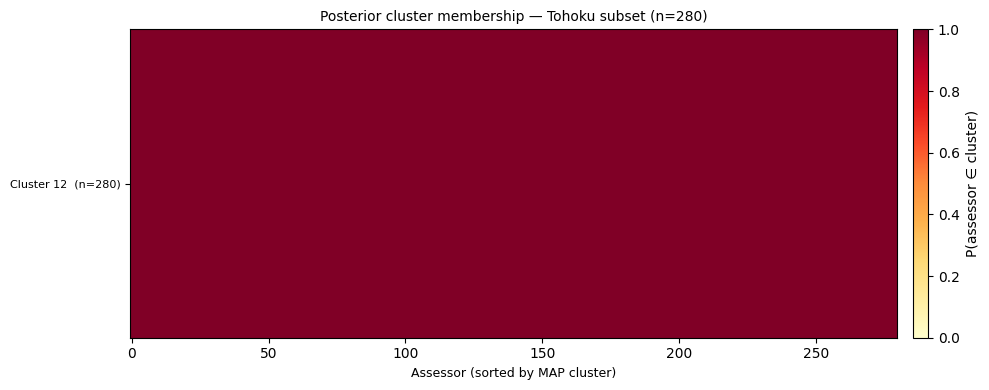


1 active clusters out of 20
Cluster sizes: Cl12=280


In [80]:
# ── Posterior cluster membership heatmap (Tohoku) ─────────────────────────────
import matplotlib.pyplot as plt

z_arr_t   = np.array(samples_tohoku.z_samples, dtype=np.intp)
T_samp_t  = z_arr_t.shape[0]
N_assess_t = z_arr_t.shape[1]

z_map_t = map_result_tohoku["z"]

membership_t = np.zeros((N_assess_t, C_tohoku), dtype=np.float32)
for t in range(T_samp_t):
    membership_t[np.arange(N_assess_t), z_arr_t[t]] += 1
membership_t /= T_samp_t

z_map_arr_t  = np.array(z_map_t, dtype=int)
confidence_t = membership_t[np.arange(N_assess_t), z_map_arr_t]
sort_ord_t   = np.lexsort((-confidence_t, z_map_arr_t))
boundaries_t = np.where(np.diff(z_map_arr_t[sort_ord_t]))[0]

cluster_sizes_t = np.array([(z_map_arr_t == c).sum() for c in range(C_tohoku)])
active_clusters_t = [c for c in np.argsort(-cluster_sizes_t) if cluster_sizes_t[c] > 0]

mem_display_t = membership_t[sort_ord_t][:, active_clusters_t]

fig, ax = plt.subplots(figsize=(max(10, N_assess_t * 0.02 + 4), max(4, len(active_clusters_t) * 0.4 + 2)))
im = ax.imshow(mem_display_t.T, vmin=0, vmax=1, cmap="YlOrRd", aspect="auto", interpolation="nearest")
for b in boundaries_t:
    ax.axvline(b + 0.5, color="white", lw=0.9, alpha=0.9)

ax.set_yticks(range(len(active_clusters_t)))
ax.set_yticklabels([f"Cluster {c}  (n={cluster_sizes_t[c]})" for c in active_clusters_t], fontsize=8)
ax.set_xlabel("Assessor (sorted by MAP cluster)", fontsize=9)
ax.set_title("Posterior cluster membership — Tohoku subset (n=280)", fontsize=10)
plt.colorbar(im, ax=ax, label="P(assessor ∈ cluster)", fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

print(f"\n{len(active_clusters_t)} active clusters out of {C_tohoku}")
print(f"Cluster sizes: {', '.join(f'Cl{c}={cluster_sizes_t[c]}' for c in active_clusters_t)}")

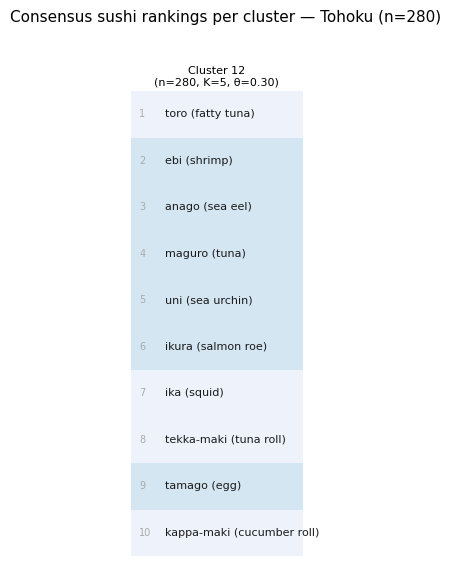

Showing 1/20 clusters (filter: ≥5 assessors)


In [74]:
# ── Consensus rankings per cluster (Tohoku) ───────────────────────────────────
import matplotlib.pyplot as plt

MIN_ASSESSORS_T = 5
n_ranked_t = rankings_tohoku.shape[1]

cluster_order_t = [c for c in active_clusters_t if cluster_sizes_t[c] >= MIN_ASSESSORS_T]

sushi_names_t = SUSHI_NAMES  # reuse from Tohoku cell

if not cluster_order_t:
    print("No clusters passed the filter — lower MIN_ASSESSORS_T.")
else:
    block_bg = ["#eef3fb", "#d4e6f2"]
    ncols_t = len(cluster_order_t)

    fig, axes = plt.subplots(1, ncols_t, figsize=(ncols_t * 2.2, n_ranked_t * 0.4 + 1.5), squeeze=False)

    for col, c in enumerate(cluster_order_t):
        bl = map_result_tohoku["clusters"][c]["blocks"]
        theta = map_result_tohoku["clusters"][c].get("theta", None)
        lbl = f"θ={theta:.2f}" if theta is not None else ""
        n_c = int(cluster_sizes_t[c])

        total_items = sum(len(b) for b in bl)
        ax = axes[0, col]
        ax.set_xlim(0, 1)
        ax.set_ylim(0, total_items)
        ax.invert_yaxis()
        ax.axis("off")

        rank_pos = 1
        row_i = 0
        for b_idx, block in enumerate(bl):
            toggle = b_idx % 2
            for item_idx in block:
                name = sushi_names_t.get(item_idx, f"item {item_idx}")
                ax.add_patch(plt.Rectangle((0, row_i), 1, 1, facecolor=block_bg[toggle], edgecolor="none", zorder=1))
                ax.text(0.05, row_i + 0.5, str(rank_pos), fontsize=7, va="center", ha="left", color="#aaaaaa", zorder=2)
                ax.text(0.20, row_i + 0.5, name, fontsize=8, va="center", ha="left", color="#1a1a1a", zorder=2)
                rank_pos += 1
                row_i += 1

        ax.set_title(f"Cluster {c}\n(n={n_c}, K={len(bl)}, {lbl})", fontsize=8, pad=4)

    fig.suptitle("Consensus sushi rankings per cluster — Tohoku (n=280)", fontsize=11, y=1.02)
    fig.tight_layout()
    plt.show()
    print(f"Showing {ncols_t}/{C_tohoku} clusters (filter: ≥{MIN_ASSESSORS_T} assessors)")

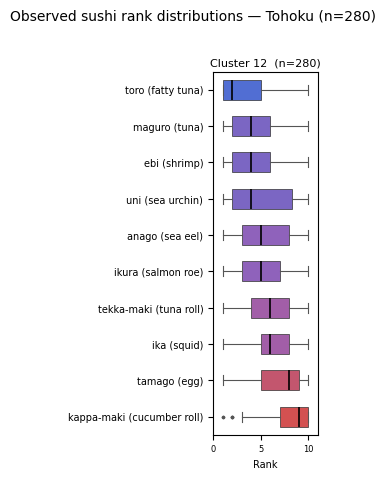

In [75]:
# ── Observed rank distributions per cluster — box plots (Tohoku) ──────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

if not cluster_order_t:
    print("No clusters to plot.")
else:
    ncols_bp_t = len(cluster_order_t)
    rank_cmap_t = mcolors.LinearSegmentedColormap.from_list("bpr", ["#3355cc", "#8844aa", "#cc3333"])

    fig_bp, axes_bp = plt.subplots(1, ncols_bp_t, figsize=(ncols_bp_t * 2.8, n_ranked_t * 0.35 + 1.2), squeeze=False)

    for col, c in enumerate(cluster_order_t):
        cl_assessors = [i for i, z in enumerate(z_map_t) if z == c]
        item_ranks = defaultdict(list)
        for ai in cl_assessors:
            for rank_0, item_idx in enumerate(rankings_tohoku[ai]):
                item_ranks[item_idx].append(rank_0 + 1)

        stats = []
        for item_idx, ranks_list in item_ranks.items():
            arr = np.array(ranks_list)
            stats.append({"item": item_idx, "name": sushi_names_t.get(item_idx, f"item {item_idx}"),
                          "median": np.median(arr), "ranks": ranks_list})
        stats.sort(key=lambda x: x["median"])

        ax = axes_bp[0, col]
        names = [s["name"] for s in stats]
        medians = [s["median"] for s in stats]
        rank_data = [s["ranks"] for s in stats]

        rank_norm = mcolors.Normalize(vmin=min(medians), vmax=max(medians))
        box_colors = [rank_cmap_t(rank_norm(m)) for m in medians]

        bp = ax.boxplot(rank_data, vert=False, patch_artist=True, widths=0.55,
                        flierprops=dict(marker=".", markersize=3, markerfacecolor="#555555",
                                        markeredgecolor="#555555", alpha=0.6),
                        medianprops=dict(color="black", linewidth=1.2),
                        whiskerprops=dict(color="#555555", linewidth=0.8),
                        capprops=dict(color="#555555", linewidth=0.8))
        for patch, fc in zip(bp["boxes"], box_colors):
            patch.set_facecolor(fc)
            patch.set_edgecolor("#333333")
            patch.set_linewidth(0.6)
            patch.set_alpha(0.85)

        ax.set_yticks(range(1, len(stats) + 1))
        ax.set_yticklabels(names, fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel("Rank", fontsize=7)
        ax.set_title(f"Cluster {c}  (n={cluster_sizes_t[c]})", fontsize=8, pad=4)
        ax.tick_params(axis="x", labelsize=6)
        ax.set_xlim(0, n_ranked_t + 1)

    fig_bp.suptitle("Observed sushi rank distributions — Tohoku (n=280)", fontsize=10, y=1.01)
    fig_bp.tight_layout()
    plt.show()

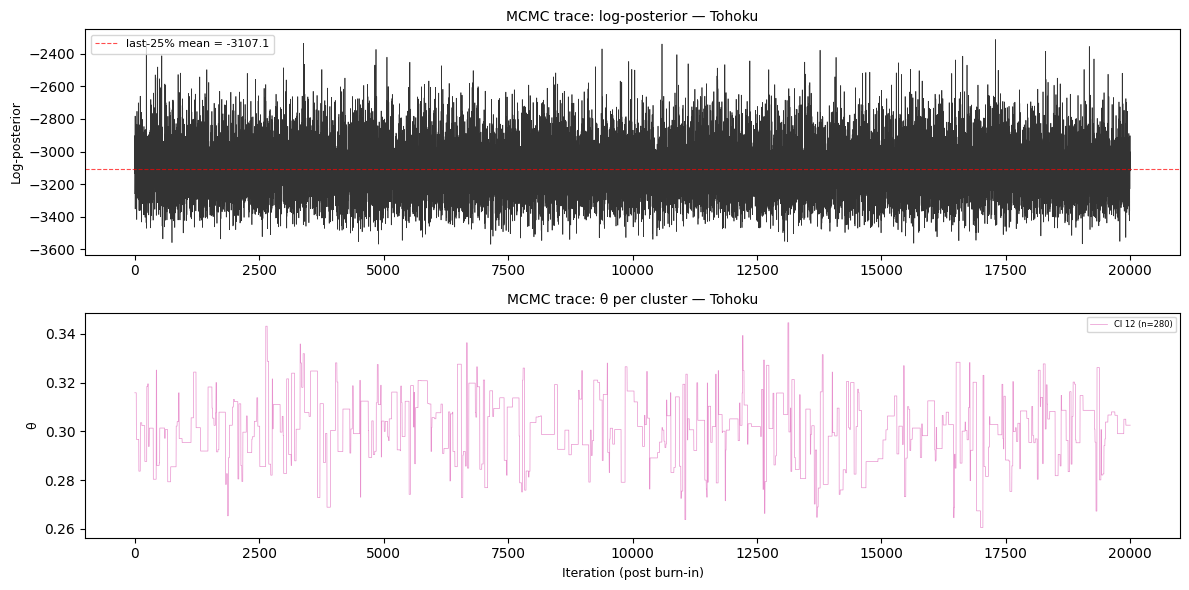

In [76]:
# ── MCMC diagnostics (Tohoku) ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

has_logp_t  = hasattr(samples_tohoku, "logp") and samples_tohoku.logp is not None
has_theta_t = hasattr(samples_tohoku, "theta_samples") and samples_tohoku.theta_samples is not None
n_panels_t  = int(has_logp_t) + int(has_theta_t)

if n_panels_t == 0:
    print("No logp or theta samples saved.")
else:
    fig, axes = plt.subplots(n_panels_t, 1, figsize=(12, 3 * n_panels_t), squeeze=False)
    ax_idx = 0

    if has_logp_t:
        logp_t = np.array(samples_tohoku.logp)
        ax = axes[ax_idx, 0]
        ax.plot(logp_t, lw=0.5, color="#333333")
        ax.set_ylabel("Log-posterior", fontsize=9)
        ax.set_title("MCMC trace: log-posterior — Tohoku", fontsize=10)
        tail = logp_t[-len(logp_t)//4:]
        ax.axhline(tail.mean(), color="red", ls="--", lw=0.8, alpha=0.7,
                   label=f"last-25% mean = {tail.mean():.1f}")
        ax.legend(fontsize=8)
        ax_idx += 1

    if has_theta_t:
        theta_arr_t = np.array(samples_tohoku.theta_samples)
        ax = axes[ax_idx, 0]
        cmap_theta_t = plt.get_cmap("tab20", C_tohoku)
        for c in active_clusters_t:
            ax.plot(theta_arr_t[:, c], lw=0.5, color=cmap_theta_t(c), alpha=0.8,
                    label=f"Cl {c} (n={cluster_sizes_t[c]})")
        ax.set_ylabel("θ", fontsize=9)
        ax.set_xlabel("Iteration (post burn-in)", fontsize=9)
        ax.set_title("MCMC trace: θ per cluster — Tohoku", fontsize=10)
        ax.legend(fontsize=6, ncol=4, loc="upper right")

    plt.tight_layout()
    plt.show()